# Sprint 1 — Baseline RAG Pipeline and Final Controlled Baseline

**Project:** CONTEXT MATTERS — Evaluating Diversity-Aware Retrieval for RAG

This notebook documents the Sprint 1 baseline pipeline and the final controlled baseline that was later frozen for the complete project.

The notebook has two goals:

1. explain the baseline RAG pipeline and the choices made in Sprint 1;
2. report the frozen baseline results that are used as the comparison point for later diversification experiments.

No scientific experiment is rerun here. The notebook reads existing frozen artifacts and summarizes them.

## 0. Historical Sprint 1 and the final controlled baseline

Two stages must be kept separate.

### Historical Sprint 1

Sprint 1 established the first working baseline pipeline, including corpus preparation, retriever integration, generation, and baseline evaluation.

Historical notebooks:

- `notebooks/01_sprint1_baseline_rag.ipynb`
- `notebooks/Sprint1_Baseline_RAG_Evaluation.ipynb`

### Final controlled baseline

Later sprints completed a larger and more controlled experiment matrix across all final datasets and generators.  
For the final project, the relevance-only condition `none` is the controlled baseline used for comparison with diversification methods.

Therefore, this notebook does **not** claim that every result shown below was generated during the original historical Sprint 1.  
It reports the final frozen baseline while preserving the historical Sprint 1 provenance.

## 1. Baseline RAG pipeline

Retrieval-Augmented Generation (RAG) combines information retrieval with an LLM.

For a question \(q\):

1. a retriever searches a corpus \(D\);
2. the retriever assigns a relevance score \(s(q,d)\) to each candidate passage \(d\);
3. the highest-scoring candidates are kept;
4. the final context is given to an LLM;
5. the LLM generates an answer using the retrieved evidence.

The baseline pipeline used in the final controlled experiment is:

\[
q
\rightarrow
\text{Retriever}
\rightarrow
\text{Top-20 candidates}
\rightarrow
\text{Top-5 by relevance}
\rightarrow
\text{LLM}
\rightarrow
\text{Answer}
\]

There is **no diversification step** in the baseline condition.

### Symbols

- \(q\): input question
- \(D\): retrieval corpus
- \(d\): one document or passage
- \(s(q,d)\): retriever relevance score
- \(k\): number of retained passages
- \(k=5\): final context size in this project

## 2. Frozen dataset scope

The final baseline uses the maximum valid retriever coverage available for each dataset.

| Dataset | Questions | Retrieval corpus | Retrieval unit | Available retrievers |
|---|---:|---:|---|---|
| PubMedQA | 1,000 | 3,358 | section/document unit in the frozen corpus | BM25, DPR, Contriever, ColBERTv2 |
| HotpotQA | 7,405 | 5,233,329 | BEIR corpus document | BM25, DPR, Contriever, ColBERTv2 |
| ASQA | 948 | 21,015,324 | DPR Wikipedia 2018-12-20 passage | BM25, DPR, Contriever |

ASQA does not contain a final ColBERTv2 run. It must be shown as **Not run**, not as zero.

In [1]:
from pathlib import Path
import json
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path("/pfs/work9/workspace/scratch/ma_rthummar-context_matters_sprint3")
SRC = ROOT / "context-matters-rag-sprint3"

OUT = ROOT / "results/final_notebooks/sprint1_baseline_v2"
TABLE_DIR = OUT / "tables"
FIGURE_DIR = OUT / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

dataset_overview = pd.DataFrame(
    [
        {
            "dataset": "PubMedQA",
            "questions": 1000,
            "corpus_units": 3358,
            "retrievers": "BM25, DPR, Contriever, ColBERTv2",
        },
        {
            "dataset": "HotpotQA",
            "questions": 7405,
            "corpus_units": 5233329,
            "retrievers": "BM25, DPR, Contriever, ColBERTv2",
        },
        {
            "dataset": "ASQA",
            "questions": 948,
            "corpus_units": 21015324,
            "retrievers": "BM25, DPR, Contriever",
        },
    ]
)

dataset_overview.to_csv(TABLE_DIR / "dataset_overview.csv", index=False)
dataset_overview

,dataset,questions,corpus_units,retrievers
0,PubMedQA,1000,3358,"BM25, DPR, Contriever, ColBERTv2"
1,HotpotQA,7405,5233329,"BM25, DPR, Contriever, ColBERTv2"
2,ASQA,948,21015324,"BM25, DPR, Contriever"


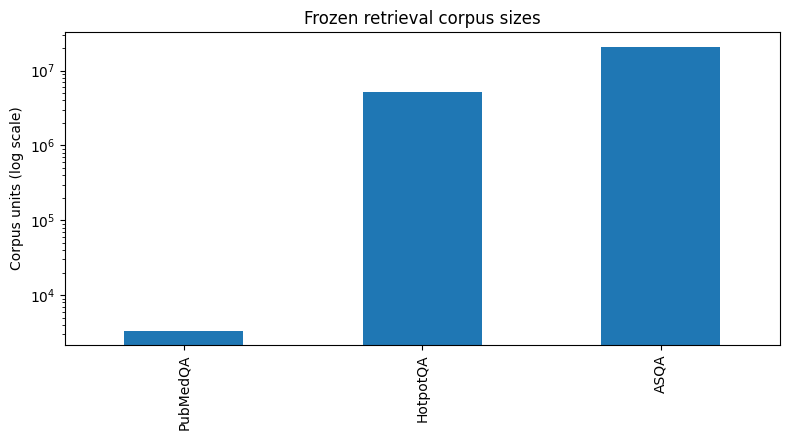

In [2]:
ax = dataset_overview.plot(
    x="dataset",
    y="corpus_units",
    kind="bar",
    legend=False,
    figsize=(8, 4.5),
)
ax.set_yscale("log")
ax.set_ylabel("Corpus units (log scale)")
ax.set_xlabel("")
ax.set_title("Frozen retrieval corpus sizes")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "dataset_corpus_sizes.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Retrieval methods

Sprint 1 integrates four retrieval approaches.

### 3.1 BM25

BM25 is a sparse lexical retriever. It rewards query terms that appear in a document while controlling for document length and term frequency.

A common BM25 form is

\[
\operatorname{BM25}(q,d)
=
\sum_{t \in q}
\operatorname{IDF}(t)
\cdot
\frac{f(t,d)(k_1+1)}
{f(t,d)+k_1\left(1-b+b\frac{|d|}{\operatorname{avgdl}}\right)}.
\]

Where:

- \(t\): a query term
- \(f(t,d)\): frequency of term \(t\) in document \(d\)
- \(\operatorname{IDF}(t)\): inverse document frequency of \(t\)
- \(|d|\): length of document \(d\)
- \(\operatorname{avgdl}\): average document length
- \(k_1,b\): BM25 parameters

PubMedQA and HotpotQA use the project BM25 implementation based on `rank_bm25.BM25Okapi`. ASQA instead uses Pyserini's prebuilt `wikipedia-dpr` Lucene index over the complete DPR Wikipedia collection with the frozen ASQA settings `k1 = 0.9` and `b = 0.4`.

The notebook does not invent parameter values that were not exposed by the frozen audit.

### 3.2 DPR

Dense Passage Retrieval (DPR) encodes the question and passage into dense vectors.

\[
\operatorname{score}(q,d)
=
E_q(q)^\top E_d(d)
\]

Where:

- \(E_q(q)\): question embedding
- \(E_d(d)\): passage embedding
- \(\top\): vector dot product

The project used the Facebook single-NQ DPR family with 768-dimensional representations.

The retrieval score is based on vector similarity rather than exact lexical overlap.

### 3.3 Contriever

Contriever is an unsupervised dense retriever.

For token embeddings \(h_1,\ldots,h_n\), attention-mask-aware mean pooling forms one sequence representation:

\[
E(x)
=
\frac{\sum_{i=1}^{n} m_i h_i}
{\sum_{i=1}^{n} m_i}.
\]

Where:

- \(h_i\): hidden representation of token \(i\)
- \(m_i \in \{0,1\}\): attention-mask value
- \(E(x)\): final embedding of text \(x\)

The frozen project configuration uses:

- model: `facebook/contriever`
- revision: `2bd46a25019aeea091fd42d1f0fd4801675cf699`
- embedding size: 768
- FAISS exact inner-product search for retrieval

The retrieval implementation uses raw inner-product scores.  
Later diversity analysis uses L2-normalized embeddings and cosine distance. These are different operations and should not be confused.

### 3.4 ColBERTv2

ColBERT represents a query and passage with token-level embeddings instead of compressing each text into one vector.

A simplified late-interaction score is

\[
\operatorname{ColBERT}(q,d)
=
\sum_{i=1}^{|q|}
\max_{j \in \{1,\ldots,|d|\}}
q_i^\top d_j.
\]

Where:

- \(q_i\): embedding of query token \(i\)
- \(d_j\): embedding of document token \(j\)
- \(\max_j\): best document-token match for one query token

The project used the canonical Stanford ColBERT implementation.  
The final ASQA matrix does not include ColBERTv2.

The notebook does not assert an exact ColBERT checkpoint identifier unless it is available in the frozen provenance.

## 4. Baseline candidate selection

All final baseline runs use:

- candidate pool: **Top-20**
- final context: **Top-5**
- baseline condition: **`none`**

For baseline retrieval, the final context is simply

\[
C_5(q)
=
\operatorname{Top5}_{d \in C_{20}(q)} s(q,d).
\]

Where:

- \(C_{20}(q)\): 20 retrieved candidates
- \(C_5(q)\): five passages given to the LLM
- \(s(q,d)\): original retriever relevance score

`none` means **relevance-only Top-5**.

It is not the same as `mmr_0`, and it is not itself a diversification treatment.

## 5. Generator configuration

Three physical LLMs are used for the final controlled baseline.

| Physical model | Historical logical identifier | Temperature | Max tokens |
|---|---|---:|---:|
| Gemma 4 26B | `gemma4-26b` | 0 | 256 PubMedQA / HotpotQA, 512 ASQA |
| Llama 3.3 70B | `llama-3.3-70b` | 0 | 256 PubMedQA / HotpotQA, 512 ASQA |
| Qwen 3.6 36B | `ministral-3-14b` historical alias | 0 | 256 PubMedQA / HotpotQA, 512 ASQA |

`temperature = 0` is a decoding control used by the generation API.  
We do not substitute \(T=0\) directly into a softmax equation because that mathematical expression would be undefined.

The generator is held fixed inside each direct retriever or diversification comparison.  
The three LLMs are replication across generators.

In [3]:
MODEL_MAP = {
    "gemma4-26b": "Gemma 4 26B",
    "llama-3.3-70b": "Llama 3.3 70B",
    "ministral-3-14b": "Qwen 3.6 36B",
    "qwen3.6-36b": "Qwen 3.6 36B",
}

generator_table = pd.DataFrame(
    [
        ["Gemma 4 26B", "gemma4-26b", 0, 256, 512],
        ["Llama 3.3 70B", "llama-3.3-70b", 0, 256, 512],
        ["Qwen 3.6 36B", "ministral-3-14b", 0, 256, 512],
    ],
    columns=[
        "physical_model",
        "logical_id_in_artifacts",
        "temperature",
        "max_tokens_pubmedqa_hotpotqa",
        "max_tokens_asqa",
    ],
)
generator_table.to_csv(TABLE_DIR / "generator_configuration.csv", index=False)
generator_table

,physical_model,logical_id_in_artifacts,temperature,max_tokens_pubmedqa_hotpotqa,max_tokens_asqa
0,Gemma 4 26B,gemma4-26b,0,256,512
1,Llama 3.3 70B,llama-3.3-70b,0,256,512
2,Qwen 3.6 36B,ministral-3-14b,0,256,512


## 6. Evaluation metrics used for the baseline

Different datasets require different metrics. Raw metric values from different datasets should not be treated as interchangeable.

### 6.1 PubMedQA correctness

Decision accuracy:

\[
\operatorname{Accuracy}
=
\frac{\text{number of correct decisions}}
{\text{number of measurable answers}}.
\]

### 6.2 HotpotQA correctness

Token-level precision and recall are

\[
P=\frac{|T_p \cap T_g|}{|T_p|},
\qquad
R=\frac{|T_p \cap T_g|}{|T_g|},
\]

and

\[
F_1 = \frac{2PR}{P+R}.
\]

Where:

- \(T_p\): tokens in the predicted answer
- \(T_g\): tokens in the gold answer
- \(P\): token precision
- \(R\): token recall

Exact Match (EM) is 1 when the normalized predicted answer exactly matches the normalized gold answer, otherwise 0.

### 6.3 ASQA correctness

The frozen ASQA evaluation reports:

- QA-EM
- QA-F1
- QA-Hit
- STR-EM
- STR-Hit

These are answer-side metrics. They are not the same as retrieval-side S-Recall or \(\alpha\)-nDCG.

### 6.4 Retrieval coverage

For one query, Recall@5 can be written as

\[
\operatorname{Recall@5}
=
\frac{|R_q \cap C_5(q)|}{|R_q|},
\]

where \(R_q\) is the set of relevant items for query \(q\).

PubMedQA reports:

- gold-document Recall@5
- MRR@5

For rank \(r_q\) of the first relevant document:

\[
\operatorname{RR@5}(q)
=
\begin{cases}
1/r_q, & r_q \le 5\\
0, & r_q > 5
\end{cases}
\]

and

\[
\operatorname{MRR@5}
=
\frac{1}{N}\sum_{q=1}^{N}\operatorname{RR@5}(q).
\]

HotpotQA reports:

- supporting-document Recall@5
- rate at which both supporting documents are retrieved

ASQA `STR-EM` and `STR-Hit` are answer-side coverage diagnostics and must not be labeled as retrieval S-Recall.

### 6.5 Retrieval diversity diagnostic

For the final Top-5 passages, retrieval diversity is the mean pairwise cosine distance.

For two normalized passage embeddings \(u_i\) and \(u_j\),

\[
\operatorname{cosine\_distance}(u_i,u_j)
=
1-u_i^\top u_j.
\]

For \(k=5\),

\[
D(q)
=
\frac{2}{k(k-1)}
\sum_{1 \le i < j \le k}
\left(1-u_i^\top u_j\right).
\]

Where:

- \(k=5\): final number of retrieved passages
- \(u_i,u_j\): L2-normalized passage embeddings
- \(D(q)\): retrieval diversity for one question

The diagnostic uses `facebook/contriever`, revision  
`2bd46a25019aeea091fd42d1f0fd4801675cf699`.

This is a manipulation/context-composition diagnostic. It is not itself a correctness score.

### 6.6 Faithfulness and hallucination

The frozen NLI artifacts contain per-answer fields for `faithfulness` and `hallucination`.

This notebook reports the stored values exactly and computes arithmetic means over the baseline condition.  
The two metrics are **not treated as mathematical complements**.

No NLI model is rerun in this notebook.

### 6.7 ASQA aspect-aware retrieval metrics

The project protocol requires the following ASQA retrieval metrics:

- SRecall@5
- \(\alpha\)-nDCG@5 with \(\alpha=0.5\)
- sensitivity at \(\alpha=0.3\) and \(0.7\)
- corpus coverability
- exact \(c^*\)

A simplified S-Recall form is

\[
\operatorname{SRecall@5}(q)
=
\frac{\text{coverable aspects retrieved in Top-5}}
{\text{coverable aspects for }q}.
\]

However, the frozen audit did **not** find a final numeric artifact for these metrics on the protected 948-question ASQA dev split.

Therefore this notebook does not invent values and does not substitute the older DEVELOPMENT (3,482) or SELECTION (871) results.

## 7. Load the frozen baseline artifacts

In [4]:
PQA_CORR = ROOT / "results/sprint2/pubmedqa/correctness_20260925/pubmedqa_correctness_summary.csv"
HOT_CORR = ROOT / "results/sprint2/hotpotqa/correctness_20260926/summary.csv"
ASQA_CORR = ROOT / "results/sprint2/asqa/correctness_20260926/asqa_correctness_summary.csv"

PQA_COV = ROOT / "results/sprint2/coverage_20260926/pubmedqa_coverage_summary.csv"
HOT_COV = ROOT / "results/sprint2/coverage_20260926/hotpotqa_coverage_summary.csv"
ASQA_COV = ROOT / "results/sprint2/coverage_20260926/asqa_coverage_summary.csv"

PQA_DIV = ROOT / "results/sprint2/pubmedqa/retrieval_diversity_20260926/pubmedqa_retrieval_diversity_summary.csv"
HOT_DIV = ROOT / "results/sprint2/hotpotqa/retrieval_diversity_20260926/hotpotqa_retrieval_diversity_summary.csv"
ASQA_DIV_DIR = ROOT / "results/sprint2/asqa/retrieval_diversity_20260926"

PHASE42 = (
    ROOT
    / "exports/phase42_nli_results_colab_20260927"
    / "extracted/phase42_nli_results_20260926"
)

ASQA_OUTDIV = (
    ROOT
    / "exports/phase45_output_diversity_20260927"
    / "asqa_output_diversity_summary.csv"
)

required = [
    PQA_CORR, HOT_CORR, ASQA_CORR,
    PQA_COV, HOT_COV, ASQA_COV,
    PQA_DIV, HOT_DIV, ASQA_OUTDIV,
]

missing = [str(p) for p in required if not p.exists()]
assert not missing, "Missing frozen artifacts:\n" + "\n".join(missing)

print("All primary frozen baseline artifacts found.")

All primary frozen baseline artifacts found.


In [5]:
def none_rows(path):
    df = pd.read_csv(path)
    if "condition" in df.columns:
        df = df[df["condition"].astype(str) == "none"].copy()
    return df

pub_corr = none_rows(PQA_CORR)
hot_corr = none_rows(HOT_CORR)
asqa_corr = none_rows(ASQA_CORR)

pub_cov = none_rows(PQA_COV)
hot_cov = none_rows(HOT_COV)
asqa_cov = none_rows(ASQA_COV)

pub_div = none_rows(PQA_DIV)
hot_div = none_rows(HOT_DIV)

print("Correctness rows:", len(pub_corr), len(hot_corr), len(asqa_corr))
print("Coverage rows:", len(pub_cov), len(hot_cov), len(asqa_cov))
print("Retrieval-diversity rows:", len(pub_div), len(hot_div))

Correctness rows: 12 12 9
Coverage rows: 4 4 9
Retrieval-diversity rows: 4 4


## 8. Baseline correctness results

The detailed tables keep every valid retriever × LLM cell.  
This is important because averaging too early can hide generator-specific variation.

In [6]:
pub_corr_display = pub_corr[
    [
        "retriever",
        "llm_logical_id",
        "total_n",
        "measurable_n",
        "correct_n",
        "decision_accuracy",
        "parse_failure_n",
    ]
].copy()
pub_corr_display["LLM"] = pub_corr_display["llm_logical_id"].map(MODEL_MAP)
pub_corr_display = pub_corr_display.drop(columns="llm_logical_id")
pub_corr_display.to_csv(TABLE_DIR / "pubmedqa_baseline_correctness_all_cells.csv", index=False)
pub_corr_display

,retriever,total_n,measurable_n,correct_n,decision_accuracy,parse_failure_n,LLM
21,bm25,1000,999,389,0.389389,1,Gemma 4 26B
22,bm25,1000,1000,656,0.656000,0,Llama 3.3 70B
23,bm25,1000,1000,603,0.603000,0,Qwen 3.6 36B
45,colbertv2,1000,1000,486,0.486000,0,Gemma 4 26B
46,colbertv2,1000,1000,708,0.708000,0,Llama 3.3 70B
47,colbertv2,1000,1000,675,0.675000,0,Qwen 3.6 36B
69,contriever,1000,999,444,0.444444,1,Gemma 4 26B
70,contriever,1000,1000,691,0.691000,0,Llama 3.3 70B
71,contriever,1000,1000,655,0.655000,0,Qwen 3.6 36B
93,dpr,1000,989,300,0.303337,11,Gemma 4 26B


In [7]:
hot_corr_display = hot_corr[
    [
        "retriever",
        "logical_model_id",
        "total_n",
        "measurable_n",
        "mean_f1",
        "mean_em",
        "parse_failure_n",
        "truncated_n",
    ]
].copy()
hot_corr_display["LLM"] = hot_corr_display["logical_model_id"].map(MODEL_MAP)
hot_corr_display = hot_corr_display.drop(columns="logical_model_id")
hot_corr_display.to_csv(TABLE_DIR / "hotpotqa_baseline_correctness_all_cells.csv", index=False)
hot_corr_display

,retriever,total_n,measurable_n,mean_f1,mean_em,parse_failure_n,truncated_n,LLM
0,bm25,7405,7388,0.363566,0.276394,14,3,Gemma 4 26B
1,bm25,7405,7354,0.522998,0.397743,2,49,Llama 3.3 70B
2,bm25,7405,7251,0.508997,0.389050,12,142,Qwen 3.6 36B
24,colbertv2,7405,7387,0.486159,0.370651,11,7,Gemma 4 26B
25,colbertv2,7405,7378,0.590988,0.452968,2,25,Llama 3.3 70B
26,colbertv2,7405,7291,0.591101,0.451653,6,108,Qwen 3.6 36B
48,contriever,7405,7394,0.366680,0.276170,3,8,Gemma 4 26B
49,contriever,7405,7344,0.530584,0.403867,2,59,Llama 3.3 70B
50,contriever,7405,7262,0.522841,0.396585,6,137,Qwen 3.6 36B
72,dpr,7405,7392,0.249866,0.183847,9,4,Gemma 4 26B


In [8]:
asqa_corr_display = asqa_corr[
    [
        "retriever",
        "logical_model_id",
        "total_n",
        "measurable_n",
        "QA-EM",
        "QA-F1",
        "QA-Hit",
        "STR-EM",
        "STR-Hit",
        "parse_failure_n",
        "truncated_n",
    ]
].copy()
asqa_corr_display["LLM"] = asqa_corr_display["logical_model_id"].map(MODEL_MAP)
asqa_corr_display = asqa_corr_display.drop(columns="logical_model_id")
asqa_corr_display.to_csv(TABLE_DIR / "asqa_baseline_correctness_all_cells.csv", index=False)
asqa_corr_display

,retriever,total_n,measurable_n,QA-EM,QA-F1,QA-Hit,STR-EM,STR-Hit,parse_failure_n,truncated_n,LLM
21,bm25,948,948,15.898383,20.604133,3.797468,26.343179,10.021097,0,0,Gemma 4 26B
22,bm25,948,944,25.810381,32.795719,6.250000,41.260593,17.055085,0,4,Llama 3.3 70B
23,bm25,948,941,19.422600,25.118009,5.100956,32.807297,14.346440,2,5,Qwen 3.6 36B
45,contriever,948,948,13.932841,18.643212,3.797468,24.129747,8.649789,0,0,Gemma 4 26B
46,contriever,948,946,23.948203,31.940005,5.391121,40.244891,15.433404,0,2,Llama 3.3 70B
47,contriever,948,945,17.650794,24.009433,4.126984,32.264550,12.804233,0,3,Qwen 3.6 36B
69,dpr,948,948,24.119198,30.268924,5.907173,38.326301,15.928270,0,0,Gemma 4 26B
70,dpr,948,945,28.156966,35.849365,5.820106,47.261023,20.846561,0,3,Llama 3.3 70B
71,dpr,948,947,25.691658,32.470737,5.807814,42.828229,19.429778,0,1,Qwen 3.6 36B


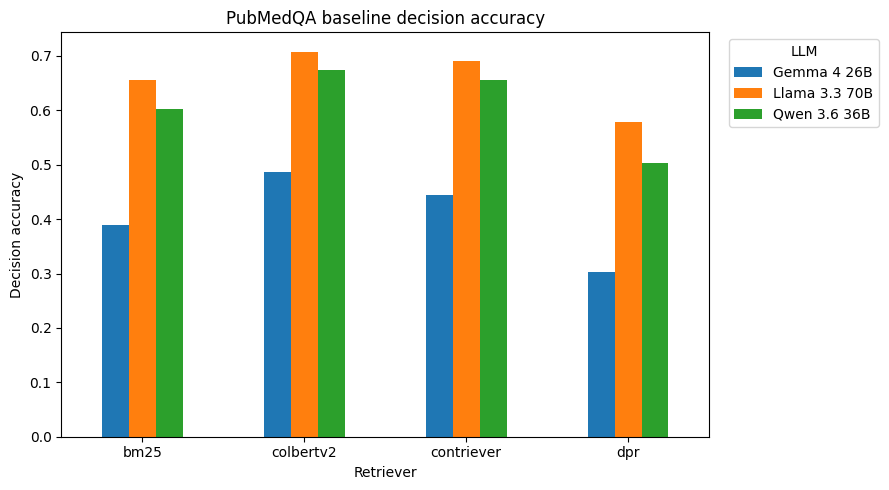

In [9]:
def grouped_bar(df, model_col, metric, title, ylabel, filename):
    p = df.pivot(index="retriever", columns=model_col, values=metric)
    p = p.rename(columns=MODEL_MAP)
    ax = p.plot(kind="bar", figsize=(9, 5))
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Retriever")
    ax.legend(title="LLM", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()

grouped_bar(
    pub_corr,
    "llm_logical_id",
    "decision_accuracy",
    "PubMedQA baseline decision accuracy",
    "Decision accuracy",
    "pubmedqa_baseline_correctness.png",
)

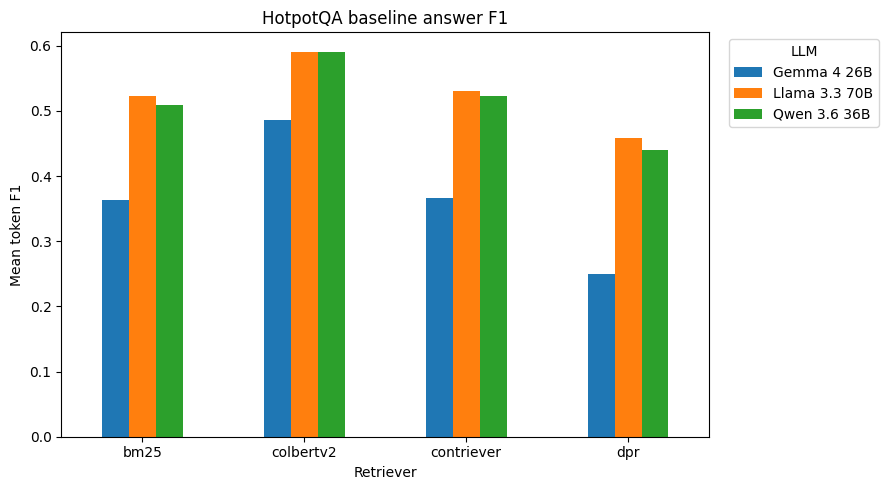

In [10]:
grouped_bar(
    hot_corr,
    "logical_model_id",
    "mean_f1",
    "HotpotQA baseline answer F1",
    "Mean token F1",
    "hotpotqa_baseline_correctness.png",
)

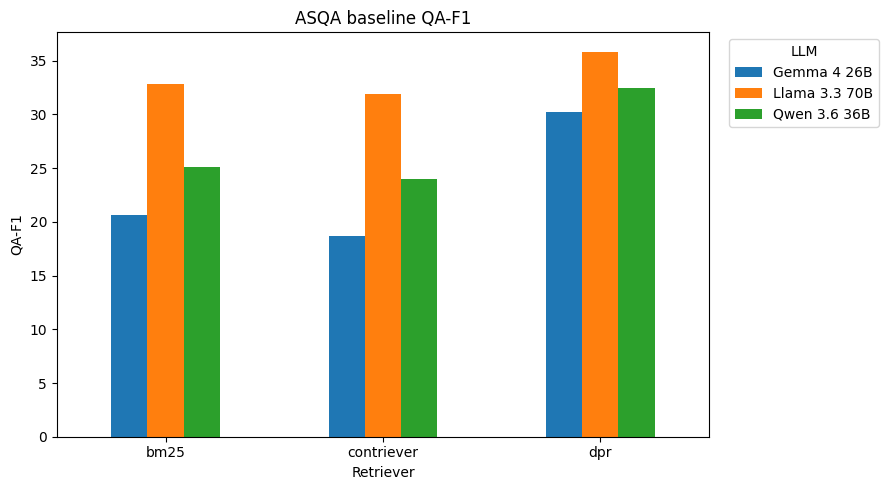

In [11]:
grouped_bar(
    asqa_corr,
    "logical_model_id",
    "QA-F1",
    "ASQA baseline QA-F1",
    "QA-F1",
    "asqa_baseline_correctness.png",
)

### Correctness interpretation

The baseline results show substantial variation across both retrievers and generators.

For the final project, the important role of these values is to define the relevance-only reference point.  
Later diversification conditions should be compared against the matching dataset, retriever, and LLM baseline rather than against a cross-dataset raw score.

## 9. Baseline retrieval and coverage results

In [12]:
pub_cov.to_csv(TABLE_DIR / "pubmedqa_baseline_retrieval_coverage.csv", index=False)
hot_cov.to_csv(TABLE_DIR / "hotpotqa_baseline_retrieval_coverage.csv", index=False)
asqa_cov.to_csv(TABLE_DIR / "asqa_baseline_answer_side_coverage.csv", index=False)

display(pub_cov)
display(hot_cov)
display(asqa_cov)

,dataset,retriever,condition,n,coverage_metric,coverage_value,secondary_metric,secondary_value
7,pubmedqa,bm25,none,1000,gold_document_recall_at_5,0.599211,mrr_at_5,0.911517
15,pubmedqa,colbertv2,none,1000,gold_document_recall_at_5,0.738210,mrr_at_5,0.976233
23,pubmedqa,contriever,none,1000,gold_document_recall_at_5,0.740371,mrr_at_5,0.972117
31,pubmedqa,dpr,none,1000,gold_document_recall_at_5,0.325259,mrr_at_5,0.578683


,dataset,retriever,condition,n,coverage_metric,coverage_value,secondary_metric,secondary_value
7,hotpotqa,bm25,none,7405,supporting_document_recall_at_5,0.437272,both_supporting_documents_retrieved_rate,0.155300
15,hotpotqa,colbertv2,none,7405,supporting_document_recall_at_5,0.635179,both_supporting_documents_retrieved_rate,0.334909
23,hotpotqa,contriever,none,7405,supporting_document_recall_at_5,0.459487,both_supporting_documents_retrieved_rate,0.155841
31,hotpotqa,dpr,none,7405,supporting_document_recall_at_5,0.281026,both_supporting_documents_retrieved_rate,0.069413


,dataset,retriever,condition,logical_model_id,n,coverage_metric,coverage_value,secondary_metric,secondary_value
21,asqa,bm25,none,gemma4-26b,948,str_em,0.263432,str_hit,0.100211
22,asqa,bm25,none,llama-3.3-70b,944,str_em,0.412606,str_hit,0.170551
23,asqa,bm25,none,ministral-3-14b,941,str_em,0.328073,str_hit,0.143464
45,asqa,contriever,none,gemma4-26b,948,str_em,0.241297,str_hit,0.086498
46,asqa,contriever,none,llama-3.3-70b,946,str_em,0.402449,str_hit,0.154334
47,asqa,contriever,none,ministral-3-14b,945,str_em,0.322646,str_hit,0.128042
69,asqa,dpr,none,gemma4-26b,948,str_em,0.383263,str_hit,0.159283
70,asqa,dpr,none,llama-3.3-70b,945,str_em,0.472610,str_hit,0.208466
71,asqa,dpr,none,ministral-3-14b,947,str_em,0.428282,str_hit,0.194298


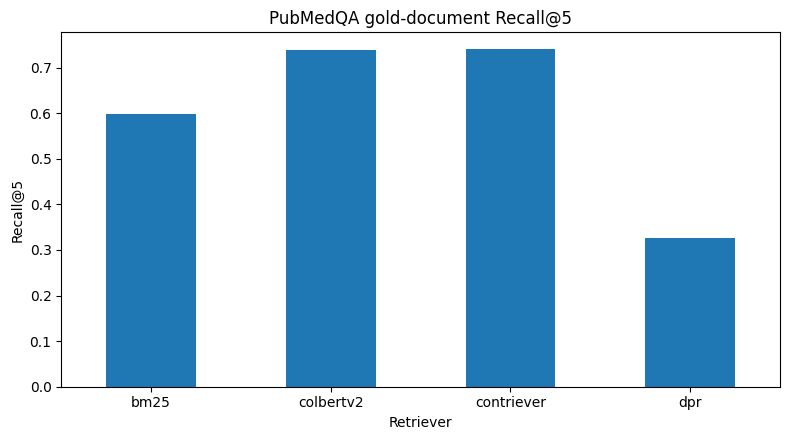

In [13]:
def simple_metric_bar(df, metric_col, title, ylabel, filename):
    ax = df.set_index("retriever")[metric_col].plot(
        kind="bar",
        figsize=(8, 4.5),
        legend=False,
    )
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Retriever")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()

simple_metric_bar(
    pub_cov,
    "coverage_value",
    "PubMedQA gold-document Recall@5",
    "Recall@5",
    "pubmedqa_baseline_retrieval_coverage.png",
)

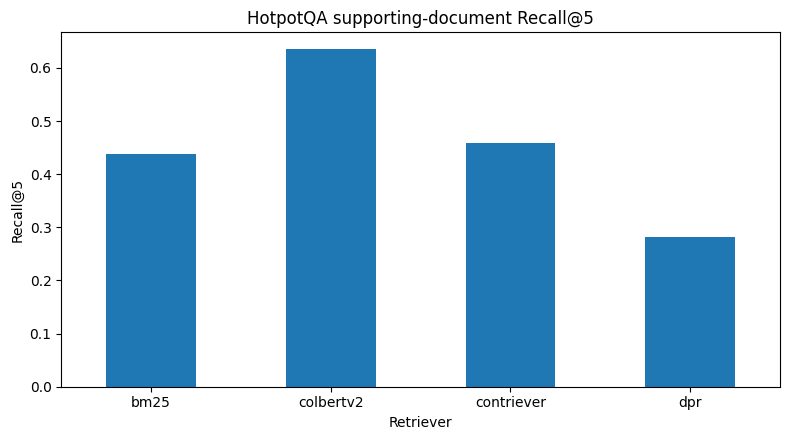

In [14]:
simple_metric_bar(
    hot_cov,
    "coverage_value",
    "HotpotQA supporting-document Recall@5",
    "Recall@5",
    "hotpotqa_baseline_retrieval_coverage.png",
)

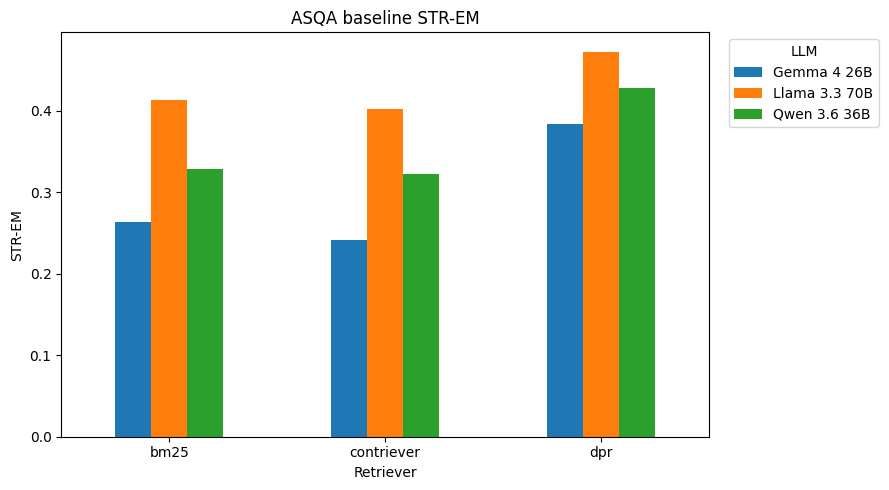

In [15]:
grouped_bar(
    asqa_cov,
    "logical_model_id",
    "coverage_value",
    "ASQA baseline STR-EM",
    "STR-EM",
    "asqa_baseline_answer_side_coverage.png",
)

### ASQA coverage warning

The ASQA table above reports `STR-EM` and `STR-Hit` from generated answers.

These are **answer-side** coverage measures.

They must not be interpreted as:

- SRecall@5
- \(\alpha\)-nDCG@5
- corpus coverability
- \(c^*\)

The final protected dev948 numeric artifact for those retrieval-side aspect metrics was not found in the frozen audit.

## 10. Baseline retrieval diversity

In [16]:
asqa_div_rows = []

for retriever in ["bm25", "dpr", "contriever"]:
    path = ASQA_DIV_DIR / (
        f"{retriever}_asqa_project_protected_final_final8_"
        "retrieval_diversity_summary_v1.json"
    )
    obj = json.loads(path.read_text())
    row = obj["conditions"]["none"]
    asqa_div_rows.append(
        {
            "dataset": "asqa",
            "retriever": retriever,
            "condition": "none",
            "n": row["questions"],
            "mean_retrieval_diversity": row["mean_retrieval_diversity"],
            "std_retrieval_diversity": row["std_retrieval_diversity"],
            "min_retrieval_diversity": row["min_retrieval_diversity"],
            "max_retrieval_diversity": row["max_retrieval_diversity"],
            "top_k": obj["top_k"],
            "candidate_pool": obj["candidate_pool"],
            "role": obj["role"],
        }
    )

asqa_div = pd.DataFrame(asqa_div_rows)

div_all = pd.concat(
    [
        pub_div.assign(dataset="pubmedqa"),
        hot_div.assign(dataset="hotpotqa"),
        asqa_div,
    ],
    ignore_index=True,
    sort=False,
)

keep = [
    "dataset",
    "retriever",
    "condition",
    "n",
    "mean_retrieval_diversity",
    "std_retrieval_diversity",
    "min_retrieval_diversity",
    "max_retrieval_diversity",
]
div_display = div_all[keep].copy()

div_display.to_csv(TABLE_DIR / "baseline_retrieval_diversity_all_datasets.csv", index=False)
div_display

,dataset,retriever,condition,n,mean_retrieval_diversity,std_retrieval_diversity,min_retrieval_diversity,max_retrieval_diversity
0,pubmedqa,bm25,none,1000,0.541484,0.070897,0.327719,0.715482
1,pubmedqa,dpr,none,1000,0.578946,0.051722,0.355364,0.719159
2,pubmedqa,contriever,none,1000,0.465760,0.057818,0.295649,0.720546
3,pubmedqa,colbertv2,none,1000,0.503260,0.062201,0.295649,0.679212
4,hotpotqa,bm25,none,7405,0.538038,0.100777,0.078922,0.781515
5,hotpotqa,dpr,none,7405,0.577808,0.086299,0.126164,0.782133
6,hotpotqa,contriever,none,7405,0.619411,0.108839,0.025543,0.826891
7,hotpotqa,colbertv2,none,7405,0.535663,0.093177,0.082723,0.753463
8,asqa,bm25,none,948,0.574373,0.113850,0.184799,0.842632
9,asqa,dpr,none,948,0.524387,0.094170,0.243850,0.792853


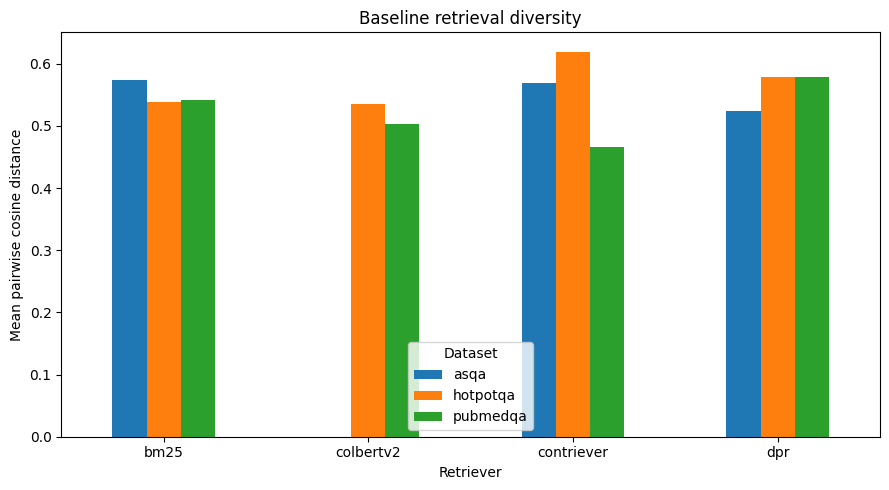

In [17]:
pivot = div_display.pivot(
    index="retriever",
    columns="dataset",
    values="mean_retrieval_diversity",
)
ax = pivot.plot(kind="bar", figsize=(9, 5))
ax.set_title("Baseline retrieval diversity")
ax.set_ylabel("Mean pairwise cosine distance")
ax.set_xlabel("Retriever")
ax.legend(title="Dataset")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "baseline_retrieval_diversity_all_datasets.png", dpi=200, bbox_inches="tight")
plt.show()

### Retrieval-diversity interpretation

The baseline itself already has non-zero semantic diversity because the Top-5 passages are not identical.

The diversity value depends on the dataset and retriever.  
It is used as a context-composition diagnostic, not as evidence that one answer is correct or incorrect.

## 11. Baseline faithfulness and hallucination

In [18]:
def load_phase42_baseline(path):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            if obj.get("condition") != "none":
                continue

            logical = obj.get("logical_model_id")
            physical = obj.get("physical_model_id") or MODEL_MAP.get(logical, logical)

            rows.append(
                {
                    "retriever": obj.get("retriever"),
                    "logical_model_id": logical,
                    "physical_model": physical,
                    "faithfulness": float(obj["faithfulness"]),
                    "hallucination": float(bool(obj["hallucination"])),
                }
            )

    df = pd.DataFrame(rows)
    return (
        df.groupby(
            ["retriever", "logical_model_id", "physical_model"],
            as_index=False,
        )
        .agg(
            n=("faithfulness", "size"),
            mean_faithfulness=("faithfulness", "mean"),
            hallucination_rate=("hallucination", "mean"),
        )
    )

phase42_tables = {}

for dataset in ["pubmedqa", "hotpotqa", "asqa"]:
    path = PHASE42 / f"{dataset}_phase42_nli.jsonl"
    assert path.exists(), path
    phase42_tables[dataset] = load_phase42_baseline(path)
    phase42_tables[dataset]["dataset"] = dataset

faith_all = pd.concat(phase42_tables.values(), ignore_index=True)
faith_all.to_csv(TABLE_DIR / "baseline_faithfulness_hallucination_all_cells.csv", index=False)

faith_all

,retriever,logical_model_id,physical_model,n,mean_faithfulness,hallucination_rate,dataset
0,bm25,gemma4-26b,gemma4-26b,999,0.653153,0.455455,pubmedqa
1,bm25,llama-3.3-70b,llama-3.3-70b,1000,0.563333,0.750000,pubmedqa
2,bm25,ministral-3-14b,qwen3.6-36b,1000,0.635000,0.577000,pubmedqa
3,colbertv2,gemma4-26b,gemma4-26b,1000,0.717000,0.409000,pubmedqa
4,colbertv2,llama-3.3-70b,llama-3.3-70b,1000,0.591583,0.752000,pubmedqa
5,colbertv2,ministral-3-14b,qwen3.6-36b,1000,0.633333,0.576000,pubmedqa
6,contriever,gemma4-26b,gemma4-26b,999,0.708208,0.408408,pubmedqa
7,contriever,llama-3.3-70b,llama-3.3-70b,1000,0.577417,0.754000,pubmedqa
8,contriever,ministral-3-14b,qwen3.6-36b,1000,0.641833,0.579000,pubmedqa
9,dpr,gemma4-26b,gemma4-26b,989,0.579373,0.530839,pubmedqa


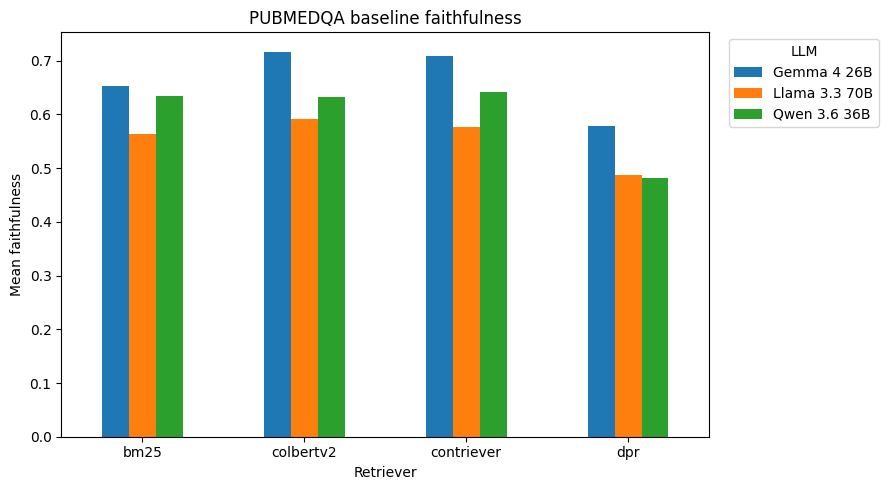

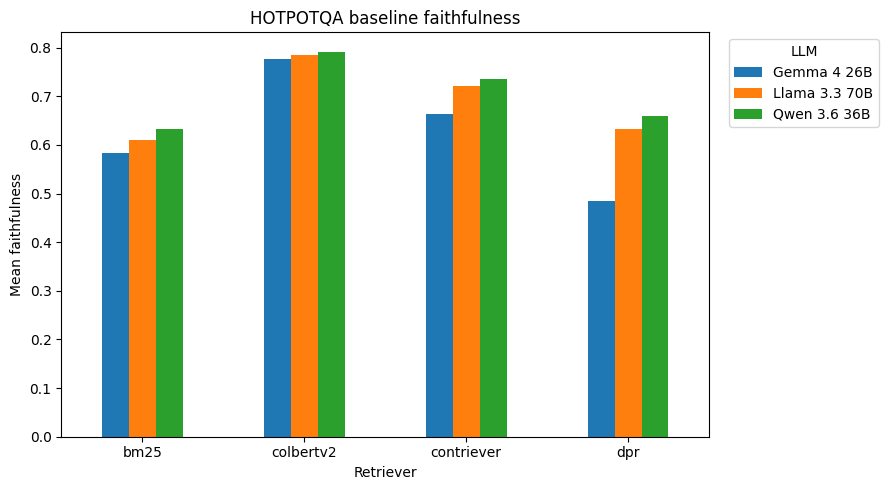

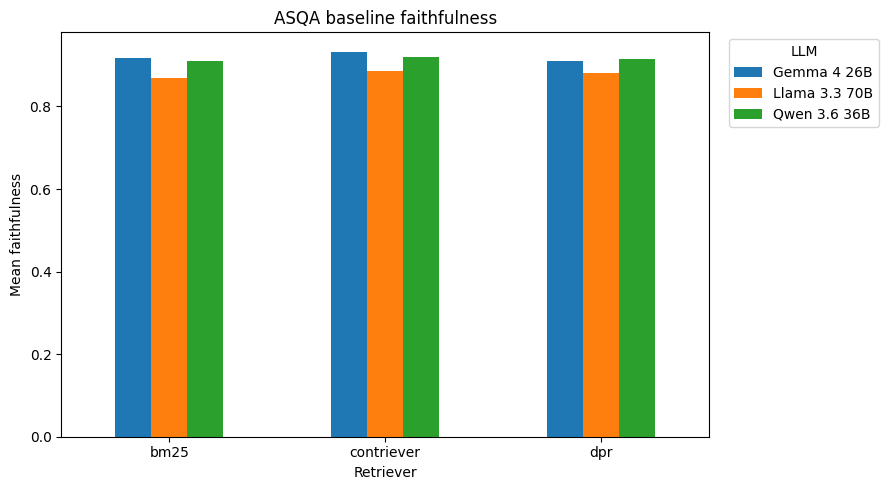

In [19]:
for dataset, df in phase42_tables.items():
    grouped_bar(
        df,
        "logical_model_id",
        "mean_faithfulness",
        f"{dataset.upper()} baseline faithfulness",
        "Mean faithfulness",
        f"{dataset}_baseline_faithfulness.png",
    )

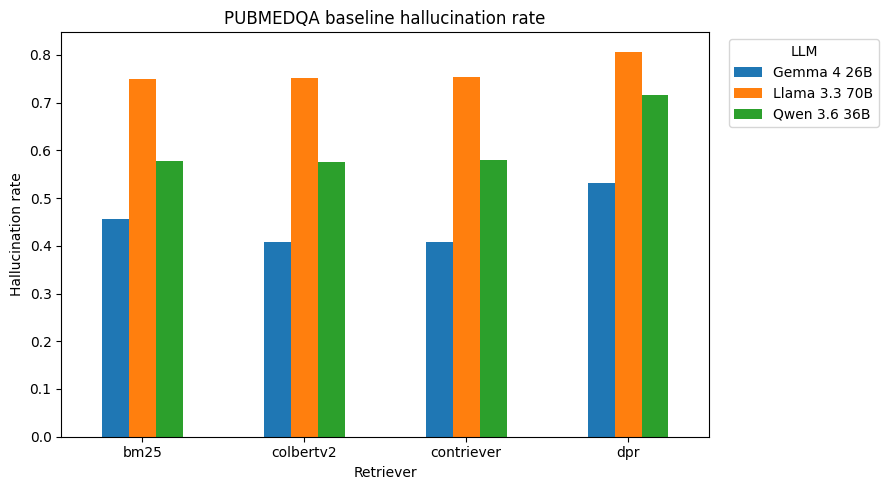

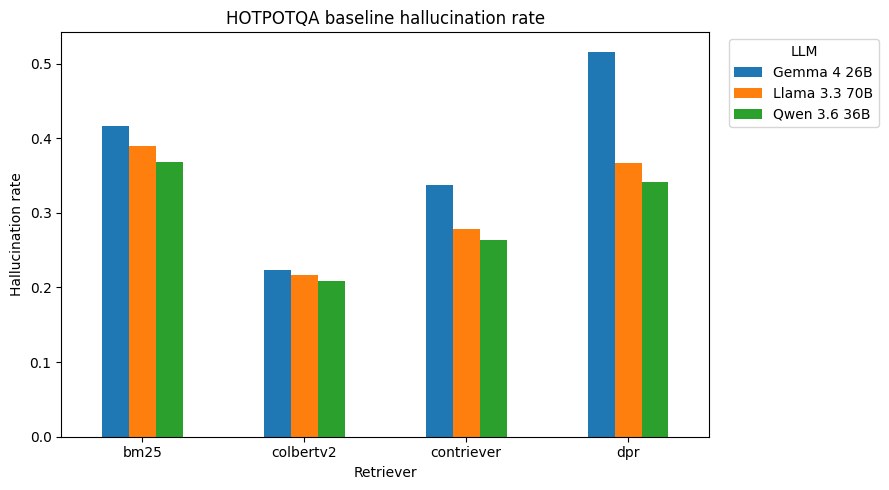

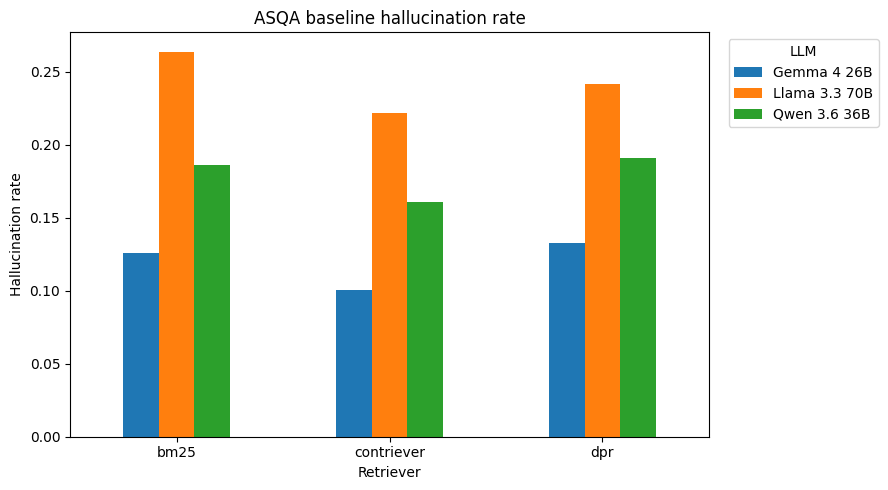

In [20]:
for dataset, df in phase42_tables.items():
    grouped_bar(
        df,
        "logical_model_id",
        "hallucination_rate",
        f"{dataset.upper()} baseline hallucination rate",
        "Hallucination rate",
        f"{dataset}_baseline_hallucination.png",
    )

### Faithfulness interpretation

Faithfulness and hallucination are reported from the frozen Phase 4.2 NLI evaluation.

They are shown separately because the stored definitions are not assumed to be exact complements.  
These values are part of the later frozen evaluation of the baseline and are not rewritten as if they were produced in the original historical Sprint 1.

## 12. ASQA baseline output diversity

In [21]:
asqa_outdiv = none_rows(ASQA_OUTDIV).copy()
asqa_outdiv["LLM"] = asqa_outdiv["logical_model_id"].map(MODEL_MAP)

asqa_outdiv_display = asqa_outdiv[
    [
        "retriever",
        "LLM",
        "answers",
        "eligible_answers",
        "ineligible_answers",
        "eligibility_fraction",
        "mean_output_diversity",
    ]
]

asqa_outdiv_display.to_csv(
    TABLE_DIR / "asqa_baseline_output_diversity_all_cells.csv",
    index=False,
)

asqa_outdiv_display

,retriever,LLM,answers,eligible_answers,ineligible_answers,eligibility_fraction,mean_output_diversity
21,bm25,Gemma 4 26B,948,376,572,0.396624,0.375877
22,bm25,Llama 3.3 70B,944,756,188,0.800847,0.379639
23,bm25,Qwen 3.6 36B,941,765,176,0.812965,0.404377
45,contriever,Gemma 4 26B,948,404,544,0.426160,0.387778
46,contriever,Llama 3.3 70B,946,769,177,0.812896,0.378478
47,contriever,Qwen 3.6 36B,945,786,159,0.831746,0.404617
69,dpr,Gemma 4 26B,948,374,574,0.394515,0.402696
70,dpr,Llama 3.3 70B,945,727,218,0.769312,0.381971
71,dpr,Qwen 3.6 36B,947,749,198,0.790919,0.403968


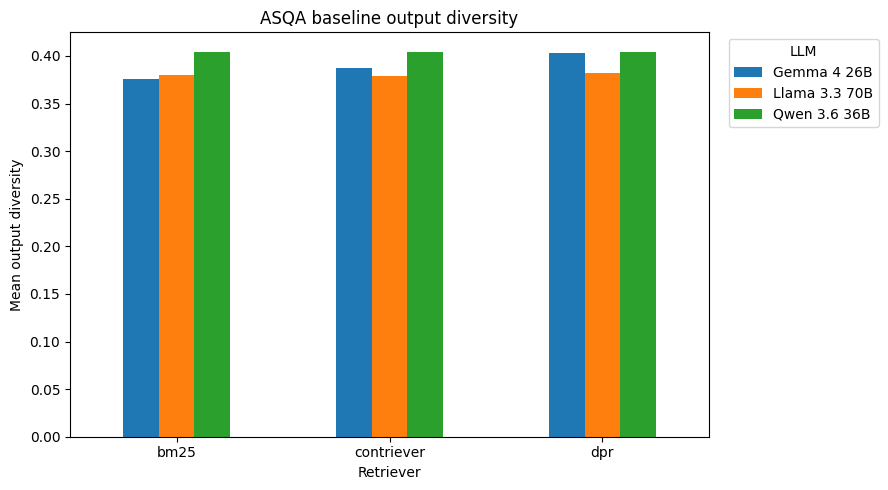

In [22]:
grouped_bar(
    asqa_outdiv,
    "logical_model_id",
    "mean_output_diversity",
    "ASQA baseline output diversity",
    "Mean output diversity",
    "asqa_baseline_output_diversity.png",
)

### Output-diversity interpretation

Output diversity is reported for ASQA because ASQA questions can contain multiple valid interpretations or aspects.

The eligibility fraction varies across generator/retriever cells, so the number of answers contributing to the output-diversity mean must be reported together with the metric.

## 13. What is available and what is not available

### Verified and reported

- corpus sizes and retriever availability
- baseline Top-20 → Top-5 design
- three-generator setup
- PubMedQA correctness
- HotpotQA correctness
- ASQA correctness
- PubMedQA retrieval coverage
- HotpotQA retrieval coverage
- ASQA answer-side STR coverage
- retrieval diversity for all valid dataset/retriever combinations
- frozen baseline faithfulness and hallucination
- ASQA baseline output diversity

### Not available as a final frozen dev948 numeric artifact

- ASQA SRecall@5
- ASQA \(\alpha\)-nDCG@5
- ASQA coverability
- ASQA exact \(c^*\)

Older ASQA DEVELOPMENT and SELECTION values must not be substituted for the protected 948-question final split.

## 14. Sprint 1 requirement checklist

| Sprint 1 requirement | Notebook status |
|---|---|
| Corpus preparation and indexing scope | Documented |
| BM25 integration | Documented |
| DPR integration | Documented |
| Contriever integration | Documented |
| ColBERTv2 integration | Documented for PubMedQA and HotpotQA |
| Fixed-generator direct comparisons | Documented |
| Relevance-only baseline | Documented |
| Correctness baseline | Reported from frozen artifacts |
| Retrieval/coverage baseline | Reported where frozen |
| Retrieval diversity diagnostic | Reported from frozen artifacts |
| Faithfulness/hallucination baseline | Reported from later frozen evaluation |
| Output diversity baseline | Reported for ASQA |
| ASQA final dev948 aspect-retrieval metrics | Not reported because no frozen numeric artifact was found |

This table makes the missing evidence explicit rather than filling the gap with an older split or an inferred value.

## 15. Exported tables and figures

In [23]:
print("TABLES")
for p in sorted(TABLE_DIR.glob("*")):
    print(" -", p.name)

print("\nFIGURES")
for p in sorted(FIGURE_DIR.glob("*")):
    print(" -", p.name)

TABLES
 - asqa_baseline_answer_side_coverage.csv
 - asqa_baseline_correctness_all_cells.csv
 - asqa_baseline_output_diversity_all_cells.csv
 - baseline_faithfulness_hallucination_all_cells.csv
 - baseline_retrieval_diversity_all_datasets.csv
 - dataset_overview.csv
 - generator_configuration.csv
 - hotpotqa_baseline_correctness_all_cells.csv
 - hotpotqa_baseline_retrieval_coverage.csv
 - pubmedqa_baseline_correctness_all_cells.csv
 - pubmedqa_baseline_retrieval_coverage.csv

FIGURES
 - asqa_baseline_answer_side_coverage.png
 - asqa_baseline_correctness.png
 - asqa_baseline_faithfulness.png
 - asqa_baseline_hallucination.png
 - asqa_baseline_output_diversity.png
 - baseline_retrieval_diversity_all_datasets.png
 - dataset_corpus_sizes.png
 - hotpotqa_baseline_correctness.png
 - hotpotqa_baseline_faithfulness.png
 - hotpotqa_baseline_hallucination.png
 - hotpotqa_baseline_retrieval_coverage.png
 - pubmedqa_baseline_correctness.png
 - pubmedqa_baseline_faithfulness.png
 - pubmedqa_baseline

## 16. Baseline takeaway

Sprint 1 established the relevance-only RAG reference point needed for the later diversity-aware experiments.

The final controlled baseline shows that:

- retrieval behavior differs across retrievers and datasets;
- answer quality also varies across generators;
- semantic diversity already exists in relevance-only Top-5 contexts;
- retrieval diversity, correctness, faithfulness, hallucination, and output diversity measure different properties and should not be collapsed into one score.

Later diversification results should therefore be evaluated as **paired changes from the matching baseline configuration**, not by comparing unrelated raw scores across datasets or generators.